# Creating data frames for looking at the IL17 gene locus

## RNAseq data frame for IL17 gene expression

First I have to import the RNAseq data set and the required packages

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [32]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq.head()

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,0610005C13Rik,1.096732,1.096732,1.021750,1.021812,1.205236,1.326780,1.392996,1.821243,1.025543,...,1.025785,1.025785,1.251082,1.147249,1.024462,1.019656,1.017884,1.019107,1.017884,1.024720
1,0610007P14Rik,206.053987,246.105317,192.424636,204.298358,189.759175,210.195155,180.219440,137.802543,139.436719,...,121.603448,105.140895,101.841463,175.620707,280.406964,200.228029,208.171821,88.578590,129.021874,140.655763
2,0610009B22Rik,78.272059,78.837030,68.844751,76.418169,106.085619,77.502817,68.213092,57.224426,56.787489,...,88.691426,73.423656,68.881268,60.811907,56.578015,100.397766,37.373080,73.888468,77.191831,84.245816
3,0610009L18Rik,8.577159,16.791386,15.511549,16.947354,10.583704,8.664784,2.878172,8.952120,11.873984,...,6.132818,8.965889,4.080445,11.987408,5.627219,4.227673,2.199352,1.460090,2.482516,1.023995
4,0610009O20Rik,168.645852,157.926022,155.941641,186.261464,162.584556,152.088002,163.072291,133.116083,88.052982,...,102.592399,147.139323,130.924354,107.542142,88.338330,100.779150,86.442408,193.307175,187.212720,45.464889


There are 5 different genes for IL17. I want a data frame with just these 5 rows and also waant to see which cell types express the most IL17.

In [33]:
RNA_seq_IL17 = RNA_seq[
    (RNA_seq["Unnamed: 0"] == "Il17a") | 
    (RNA_seq["Unnamed: 0"] == "Il17b") |
    (RNA_seq["Unnamed: 0"] == "Il17c") |
    (RNA_seq["Unnamed: 0"] == "Il17d") |
    (RNA_seq["Unnamed: 0"] == "Il17f")
    ]
RNA_seq_IL17
mean_IL17_exp = RNA_seq_IL17.iloc[:, 1:].mean()
top10_IL17_exp = mean_IL17_exp.nlargest(10)
print(top10_IL17_exp)



ILC3.CCR6+.SI            93.658243
ILC3.NKp46-CCR6-.SI      30.097171
NKT.Sp.LPS.3hr           15.317288
Tgd.g2+d17.LN            10.788941
Treg.4.FP3+.Nrplo.Co      6.810947
T.4.Sp.aCD3+CD40.18hr     3.520055
NKT.Sp.LPS.18hr           3.298333
GN.Thio.PC                2.551913
ILC3.NKp46+.SI            2.363046
B.T3.Sp                   1.877167
dtype: float64


saving the data frame as a .csv

In [34]:
RNA_seq_IL17.to_csv('data/RNA_seq_IL17.csv', index=False, header=True)
RNA_seq_IL17_check = pd.read_csv('data/RNA_seq_IL17.csv')
RNA_seq_IL17_check

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,Il17a,1.020795,1.02126,1.021750,1.021812,1.023171,1.140409,1.024462,1.025833,1.025543,...,1.025785,1.025785,1.021812,1.022767,1.024462,1.019656,1.017884,1.019107,1.017884,1.005329
1,Il17b,1.020795,1.02126,1.021750,1.021812,1.023171,1.021346,1.024462,1.025833,1.025543,...,1.025785,1.025785,1.126600,1.022767,1.024462,1.019656,1.017884,1.040295,1.017884,1.052731
2,Il17c,1.020795,1.02126,1.021750,1.021812,1.368419,1.021346,1.024462,3.296594,1.516769,...,1.025785,1.634780,1.146294,1.147249,1.685787,1.019656,1.017884,1.443479,1.017884,1.041095
3,Il17f,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.135090,1.017884,1.040295,1.017884,1.021351


We want to focus on the Tgd cell lineage. Therefore I can also reduce the number of cell types in the data frame

In [35]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]


RNA_seq_gd_IL17 = RNA_seq_IL17[Tgd_cells].copy()
RNA_seq_gd_IL17.describe()

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,1.050459,1.022363,1.024462,1.112115,1.024482,1.190615,1.077725,1.169608,1.207283,1.414439,1.025543,1.858544,10.788941
std,0.057294,0.000000,0.000000,0.174592,0.000000,0.328372,0.107461,0.211517,0.364928,0.509116,0.000000,1.412202,19.529893
min,1.021812,1.022363,1.024462,1.024819,1.024482,1.026430,1.023995,1.022363,1.024819,1.023995,1.025543,1.024819,1.023995
25%,1.021812,1.022363,1.024462,1.024819,1.024482,1.026430,1.023995,1.022363,1.024819,1.023995,1.025543,1.024819,1.023995
50%,1.021812,1.022363,1.024462,1.024819,1.024482,1.026430,1.023995,1.092558,1.024819,1.269607,1.025543,1.225836,1.023995
75%,1.050459,1.022363,1.024462,1.112115,1.024482,1.190615,1.077725,1.239803,1.207283,1.660052,1.025543,2.059562,10.788941
max,1.136401,1.022363,1.024462,1.374003,1.024482,1.683173,1.238917,1.470954,1.754676,2.094547,1.025543,3.957685,40.083782


## ATAC data frame with summits 100kb from IL17 locus

Since our goal is to connnect RNAseq data to ATACseq, it is also necessary to filter for the OCRs around the IL17 gene locus.<br>

In [36]:
ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')
ATAC_seq.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02


I only want the OCRs were one of the IL17 genes is listed in the genes.within.100Kb column

In [37]:
ATAC_seq_IL17 = ATAC_seq[ATAC_seq['genes.within.100Kb'].str.contains('Il17a|Il17b|Il17c|Il17d|Il17f', case=False, na=False)].copy()
ATAC_seq_IL17

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
1408,ImmGenATAC1219.peak_2073,chr1,20670994,0.76,1.41,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a",2.36,3.68,...,0.93,3.00,1.75,0.95,1.32,2.64,0.26,3.24,6.86,0.50
1409,ImmGenATAC1219.peak_2075,chr1,20686124,0.22,9.93,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.41,0.71,...,0.44,0.78,2.16,0.89,0.52,1.85,2.00,3.24,4.33,1.03
1410,ImmGenATAC1219.peak_2077,chr1,20700177,0.19,2.07,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",2.36,3.68,...,1.26,0.10,2.16,0.53,1.39,3.31,1.75,2.21,6.04,1.36
1411,ImmGenATAC1219.peak_2078,chr1,20701584,0.04,1.49,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.41,0.10,...,0.44,1.93,1.32,0.47,2.92,2.15,0.98,0.14,2.17,0.93
1412,ImmGenATAC1219.peak_2081,chr1,20725819,0.64,4.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.41,1.64,...,0.93,0.97,0.11,0.11,1.66,0.56,0.88,0.52,4.12,1.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334080,ImmGenATAC1219.peak_472800,chr8,122511638,0.12,2.03,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.41,3.68,...,1.76,1.39,0.66,1.79,0.52,9.17,1.10,1.54,1.64,1.03
334081,ImmGenATAC1219.peak_472802,chr8,122517685,0.05,4.72,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",4.37,4.78,...,2.42,1.39,3.19,0.53,1.72,1.27,1.52,30.62,14.86,0.53
334082,ImmGenATAC1219.peak_472803,chr8,122518322,0.07,1.56,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.41,6.07,...,1.70,0.29,1.32,0.89,0.51,0.11,0.88,4.81,2.29,1.43
334083,ImmGenATAC1219.peak_472805,chr8,122519632,0.02,1.98,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",16.15,4.78,...,1.34,1.54,0.11,0.53,1.82,1.10,0.34,1.54,0.11,0.94


saving the data set as a .csv

In [38]:
ATAC_seq_IL17.to_csv('data/ATAC_seq_IL17.csv', index=False, header=True)
ATAC_seq_IL17_check = pd.read_csv('data/ATAC_seq_IL17.csv')
ATAC_seq_IL17_check

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_2073,chr1,20670994,0.76,1.41,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a",2.36,3.68,...,0.93,3.00,1.75,0.95,1.32,2.64,0.26,3.24,6.86,0.50
1,ImmGenATAC1219.peak_2075,chr1,20686124,0.22,9.93,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.41,0.71,...,0.44,0.78,2.16,0.89,0.52,1.85,2.00,3.24,4.33,1.03
2,ImmGenATAC1219.peak_2077,chr1,20700177,0.19,2.07,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",2.36,3.68,...,1.26,0.10,2.16,0.53,1.39,3.31,1.75,2.21,6.04,1.36
3,ImmGenATAC1219.peak_2078,chr1,20701584,0.04,1.49,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.41,0.10,...,0.44,1.93,1.32,0.47,2.92,2.15,0.98,0.14,2.17,0.93
4,ImmGenATAC1219.peak_2081,chr1,20725819,0.64,4.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.41,1.64,...,0.93,0.97,0.11,0.11,1.66,0.56,0.88,0.52,4.12,1.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,ImmGenATAC1219.peak_472800,chr8,122511638,0.12,2.03,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.41,3.68,...,1.76,1.39,0.66,1.79,0.52,9.17,1.10,1.54,1.64,1.03
221,ImmGenATAC1219.peak_472802,chr8,122517685,0.05,4.72,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",4.37,4.78,...,2.42,1.39,3.19,0.53,1.72,1.27,1.52,30.62,14.86,0.53
222,ImmGenATAC1219.peak_472803,chr8,122518322,0.07,1.56,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.41,6.07,...,1.70,0.29,1.32,0.89,0.51,0.11,0.88,4.81,2.29,1.43
223,ImmGenATAC1219.peak_472805,chr8,122519632,0.02,1.98,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",16.15,4.78,...,1.34,1.54,0.11,0.53,1.82,1.10,0.34,1.54,0.11,0.94


I am again filtering for the Tgd cell lineage , but I also need the meta-data included in the original data frame

In [39]:
ATAC_seq_gd_IL17 = pd.concat([ATAC_seq_IL17[[
        "ImmGenATAC1219.peakID",
        "chrom",
        "Summit",
        "mm10.60way.phastCons_scores",
        "_-log10_bestPvalue",
        "Included.in.systematic.analysis",
        "TSS", 
        "genes.within.100Kb"
    ]],
    ATAC_seq_IL17[Tgd_cells[1:]].copy()], axis=1)
ATAC_seq_gd_IL17

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
1408,ImmGenATAC1219.peak_2073,chr1,20670994,0.76,1.41,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a",3.49,0.40,...,1.75,2.83,0.78,1.02,1.08,0.11,2.37,0.46,1.95,7.28
1409,ImmGenATAC1219.peak_2075,chr1,20686124,0.22,9.93,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",1.58,2.09,...,0.51,0.10,1.02,2.02,1.08,2.91,4.33,2.35,4.17,56.70
1410,ImmGenATAC1219.peak_2077,chr1,20700177,0.19,2.07,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.83,3.77,...,2.82,3.07,2.24,3.00,5.23,8.36,3.55,2.77,1.95,4.15
1411,ImmGenATAC1219.peak_2078,chr1,20701584,0.04,1.49,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",1.58,0.40,...,0.11,0.10,2.29,0.11,0.76,1.48,1.04,3.12,0.68,2.60
1412,ImmGenATAC1219.peak_2081,chr1,20725819,0.64,4.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.83,0.46,...,0.51,0.10,1.27,3.00,4.76,7.48,1.46,0.64,1.91,26.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334080,ImmGenATAC1219.peak_472800,chr8,122511638,0.12,2.03,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.11,0.40,...,0.87,0.61,0.35,0.11,4.83,2.62,1.82,2.20,1.95,2.21
334081,ImmGenATAC1219.peak_472802,chr8,122517685,0.05,4.72,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",3.49,2.61,...,1.78,0.22,1.88,0.89,1.42,1.47,1.29,0.46,0.12,1.48
334082,ImmGenATAC1219.peak_472803,chr8,122518322,0.07,1.56,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.11,0.46,...,0.11,1.69,3.17,0.89,0.59,3.13,1.04,2.63,0.68,0.13
334083,ImmGenATAC1219.peak_472805,chr8,122519632,0.02,1.98,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",3.04,1.76,...,1.40,1.03,1.51,0.11,2.08,1.64,0.15,1.62,1.95,0.13


# Looking at the IL17 locus in different cell types 

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

As a first step I load the RNAseq data an move the gene names into the index

In [41]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq = pd.read_csv('data/mmc2.csv')

RNA_seq_gd = RNA_seq[Tgd_cells[1:]].copy()

RNA_seq_val = RNA_seq.drop(columns="Unnamed: 0").copy()
RNA_seq_val.index = RNA_seq["Unnamed: 0"]

## loading the IL17 data sets

loading the data frames created in the previous section

In [42]:
RNA_seq_IL17 = pd.read_csv('data/RNA_seq_IL17.csv')

RNA_seq_IL17_val = RNA_seq_IL17.drop(columns="Unnamed: 0").copy()
RNA_seq_IL17_val.index = RNA_seq_IL17["Unnamed: 0"]

RNA_seq_IL17_val


,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Il17a,1.020795,1.02126,1.021750,1.021812,1.023171,1.140409,1.024462,1.025833,1.025543,1.024819,...,1.025785,1.025785,1.021812,1.022767,1.024462,1.019656,1.017884,1.019107,1.017884,1.005329
Il17b,1.020795,1.02126,1.021750,1.021812,1.023171,1.021346,1.024462,1.025833,1.025543,1.024819,...,1.025785,1.025785,1.126600,1.022767,1.024462,1.019656,1.017884,1.040295,1.017884,1.052731
Il17c,1.020795,1.02126,1.021750,1.021812,1.368419,1.021346,1.024462,3.296594,1.516769,3.383058,...,1.025785,1.634780,1.146294,1.147249,1.685787,1.019656,1.017884,1.443479,1.017884,1.041095
Il17f,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,1.024819,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.135090,1.017884,1.040295,1.017884,1.021351


In [43]:
ATAC_seq_IL17 = pd.read_csv('data/ATAC_seq_IL17.csv')

### were is IL17 expressed?

looking for cells expressing one IL17 gene above the threshold<br>
The threshold choosen is quite arbitrary.

In [44]:
IL17_expr_cells_RNA = RNA_seq_IL17_val[RNA_seq_IL17_val.columns[RNA_seq_IL17_val.max(axis=0) > 10]].copy()
IL17_expr_cells_RNA
                

,T.4.Sp.aCD3+CD40.18hr,Treg.4.FP3+.Nrplo.Co,NKT.Sp.LPS.3hr,Tgd.g2+d17.LN,ILC3.NKp46-CCR6-.SI,ILC3.CCR6+.SI
Unnamed: 0,,,,,,
Il17a,1.025785,23.987840,34.636492,1.023995,42.175516,104.836685
Il17b,1.025785,1.024859,1.025833,1.023995,1.022363,1.023171
Il17c,1.565833,1.206231,1.025833,1.023995,1.271327,1.023171
Il17f,10.462818,1.024859,24.580994,40.083782,75.919477,267.749944


The following code reduces the number of cell types in the ATACseq data to those expressing IL17. One additional cell type is added as a reference as it is the closest to IL17 producing Tgd cells acroding to their chromatin footprint (determined with the hierarchical clustering based on ATACseq data).

In [45]:
IL17_expr_cells_ATAC = ATAC_seq_IL17[RNA_seq_IL17_val.columns[RNA_seq_IL17_val.max(axis=0) > 10]].copy()
IL17_expr_cells_ATAC[ATAC_seq_IL17.columns[0:8]] = ATAC_seq_IL17[ATAC_seq_IL17.columns[0:8]]
IL17_expr_cells_ATAC["Tgd.g2+d1.LN"] = ATAC_seq_IL17["Tgd.g2+d1.LN"] #as a reference

## IL17f

IL17f is the only IL17 gene expressed in Tgd cells. Therefore it is further analysed.

### plotting OCRs near the IL17f gene locus

To plot the OCRs around the gene locus I need to know the transcription start and end.

In [46]:
gene_annotations = pd.read_csv('data/gene_annotations.csv')
IL17_genes = gene_annotations[gene_annotations['gene_name'].str.contains('Il17a|Il17b|Il17c|Il17d|Il17f', case=False, na=False)].copy()
IL17_genes

,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
2079,Il17a,NM_010552,chr1,+,20730904,20734496,20730961,20733859,3,"20730904,20732095,20733621,","20730988,20732307,20734496,"
4195,Il17b,NM_019508,chr18,+,61687934,61692537,61687983,61692437,3,"61687934,61690117,61692205,","61688004,61690407,61692537,"
8932,Il17f,NM_145856,chr1,-,20777145,20784270,20777766,20784199,3,"20777145,20779290,20784172,","20778004,20779511,20784270,"
34980,Il17c,NM_145834,chr8,+,122422019,122423639,122422118,122423568,2,"122422019,122423306,","122422405,122423639,"
36895,Il17d,NM_145837,chr14,+,57524828,57543166,57524906,57542640,3,"57524828,57525303,57542333,","57524921,57525599,57543166,"


In [47]:
IL17f_start = IL17_genes.loc[8932, "txEnd"]
IL17f_end = IL17_genes.loc[8932, "txStart"]

Now I only need the OCRs, that are within 100 kb of Il17f.

In [48]:
ATAC_seq_IL17f = IL17_expr_cells_ATAC[IL17_expr_cells_ATAC['genes.within.100Kb'].str.contains('Il17f', case=False, na=False)].copy()
ATAC_seq_IL17f

,T.4.Sp.aCD3+CD40.18hr,Treg.4.FP3+.Nrplo.Co,NKT.Sp.LPS.3hr,Tgd.g2+d17.LN,ILC3.NKp46-CCR6-.SI,ILC3.CCR6+.SI,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,Tgd.g2+d1.LN
1,2.14,1.89,5.04,56.70,26.18,32.45,ImmGenATAC1219.peak_2075,chr1,20686124,0.22,9.93,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",4.17
2,2.76,2.73,2.87,4.15,2.09,6.65,ImmGenATAC1219.peak_2077,chr1,20700177,0.19,2.07,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",1.95
3,1.12,1.89,1.09,2.60,0.57,0.15,ImmGenATAC1219.peak_2078,chr1,20701584,0.04,1.49,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.68
4,1.16,2.11,4.08,26.14,19.37,17.47,ImmGenATAC1219.peak_2081,chr1,20725819,0.64,4.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",1.91
5,2.76,3.01,2.12,13.28,11.12,16.75,ImmGenATAC1219.peak_2083,chr1,20738699,0.19,3.41,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",1.95
6,8.52,7.02,4.96,25.00,35.01,42.39,ImmGenATAC1219.peak_2084,chr1,20740472,0.00,13.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",6.71
7,12.49,9.83,8.79,71.34,67.30,58.74,ImmGenATAC1219.peak_2085,chr1,20740740,0.34,24.17,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",18.62
8,2.02,17.36,0.95,69.89,2.65,0.15,ImmGenATAC1219.peak_2086,chr1,20744070,0.00,7.53,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",5.03
9,0.38,1.99,1.14,0.13,0.95,1.41,ImmGenATAC1219.peak_2087,chr1,20748728,0.45,2.59,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.12
10,2.29,6.33,11.87,44.26,32.10,28.01,ImmGenATAC1219.peak_2089,chr1,20754593,0.29,8.58,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",1.95


The only meta-data needed for plotting the OCRs is the position of the summit.

In [49]:
IL17f_data = ATAC_seq_IL17f.iloc[:, 0:6].copy()
IL17f_data["Summit"] = ATAC_seq_IL17f["Summit"]
IL17f_data.insert(0, "Tgd.g2+d1.LN", ATAC_seq_IL17f["Tgd.g2+d1.LN"])
IL17f_data

,Tgd.g2+d1.LN,T.4.Sp.aCD3+CD40.18hr,Treg.4.FP3+.Nrplo.Co,NKT.Sp.LPS.3hr,Tgd.g2+d17.LN,ILC3.NKp46-CCR6-.SI,ILC3.CCR6+.SI,Summit
1,4.17,2.14,1.89,5.04,56.70,26.18,32.45,20686124
2,1.95,2.76,2.73,2.87,4.15,2.09,6.65,20700177
3,0.68,1.12,1.89,1.09,2.60,0.57,0.15,20701584
4,1.91,1.16,2.11,4.08,26.14,19.37,17.47,20725819
5,1.95,2.76,3.01,2.12,13.28,11.12,16.75,20738699
6,6.71,8.52,7.02,4.96,25.00,35.01,42.39,20740472
7,18.62,12.49,9.83,8.79,71.34,67.30,58.74,20740740
8,5.03,2.02,17.36,0.95,69.89,2.65,0.15,20744070
9,0.12,0.38,1.99,1.14,0.13,0.95,1.41,20748728
10,1.95,2.29,6.33,11.87,44.26,32.10,28.01,20754593


The following code plots the OCRs around the Il17f gene locus as a bar plot. The bars are 250 bp wide, because that is the distance in which one summit is called.

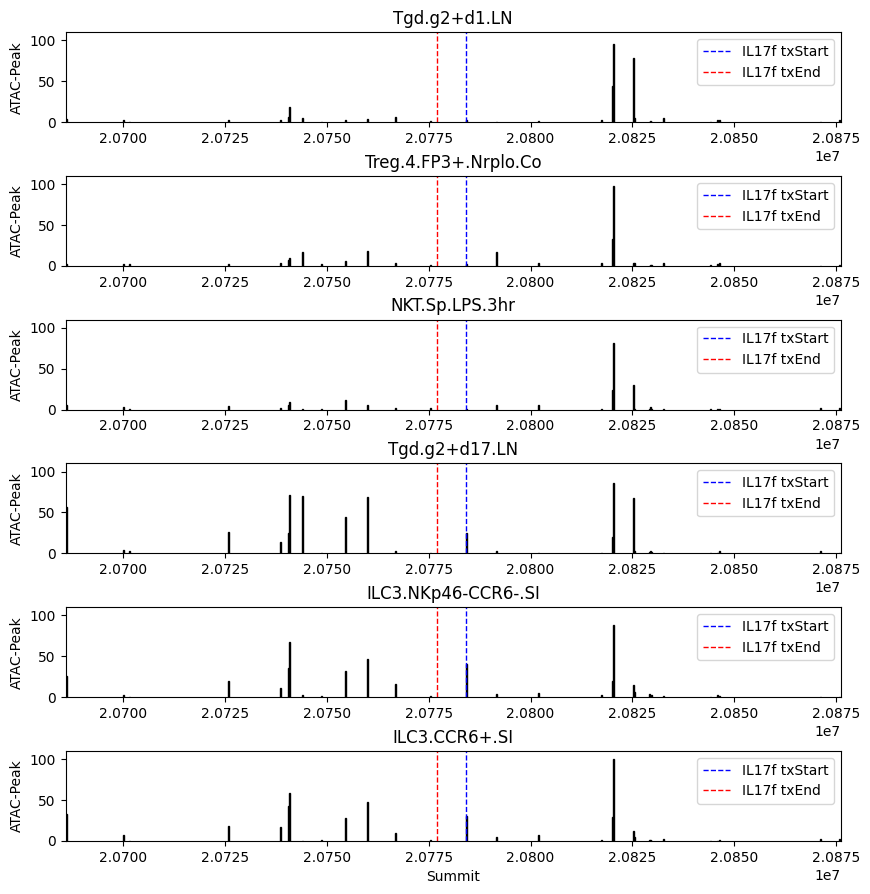

In [50]:
summits = "Summit"
cell_types = ["Tgd.g2+d1.LN",
            "Treg.4.FP3+.Nrplo.Co",
            "NKT.Sp.LPS.3hr",
            "Tgd.g2+d17.LN",
            "ILC3.NKp46-CCR6-.SI",
            "ILC3.CCR6+.SI",
]


fig, axs = plt.subplots(6, 1, figsize=(10, 10.5), sharex=False, gridspec_kw={"hspace": 0.6})


IL17f_data = IL17f_data.sort_values(summits)

x = IL17f_data[summits].to_list()


for ax, cell_type, t in zip(axs, cell_types, cell_types):
    y = IL17f_data[cell_type].to_list()

    ax.bar(x, y, width=250, color="black", edgecolor="black")
    ax.set_title(t)
    ax.set_ylabel("ATAC-Peak")
    ax.axvline(IL17f_start, color='blue', linestyle='--', linewidth=1, label='IL17f txStart')
    ax.axvline(IL17f_end, color='red', linestyle='--', linewidth=1, label='IL17f txEnd')
    ax.legend()
    ax.set_ylim(0, 110)
    ax.set_xlim(min(x) - 250, max(x) + 250)

axs[-1].set_xlabel("Summit")

plt.savefig('plots_for_poster/ATAC-peaks around the IL17f gene locus', dpi=300)
plt.show()


- the clearest difference between those cell types, which express IL17f and those, which do not, is the OCR at the TSS
- one OCR upstream is active everywhere
- another OCR upstream is especially active in both Tgd cell types
- in IL17f expressing cells there seem to be more active OCRs downstream from the gene
- the OCR-pattern of NK.Sp.LPS.3hr looks similar to those cells not expressing IL17f, even though they do express some IL17f (expression value: 25)
- peak at 2744000 is unique to Tgd.g2+d17.LN

Data from UCSC Genome Browser on Mouse as a comparison

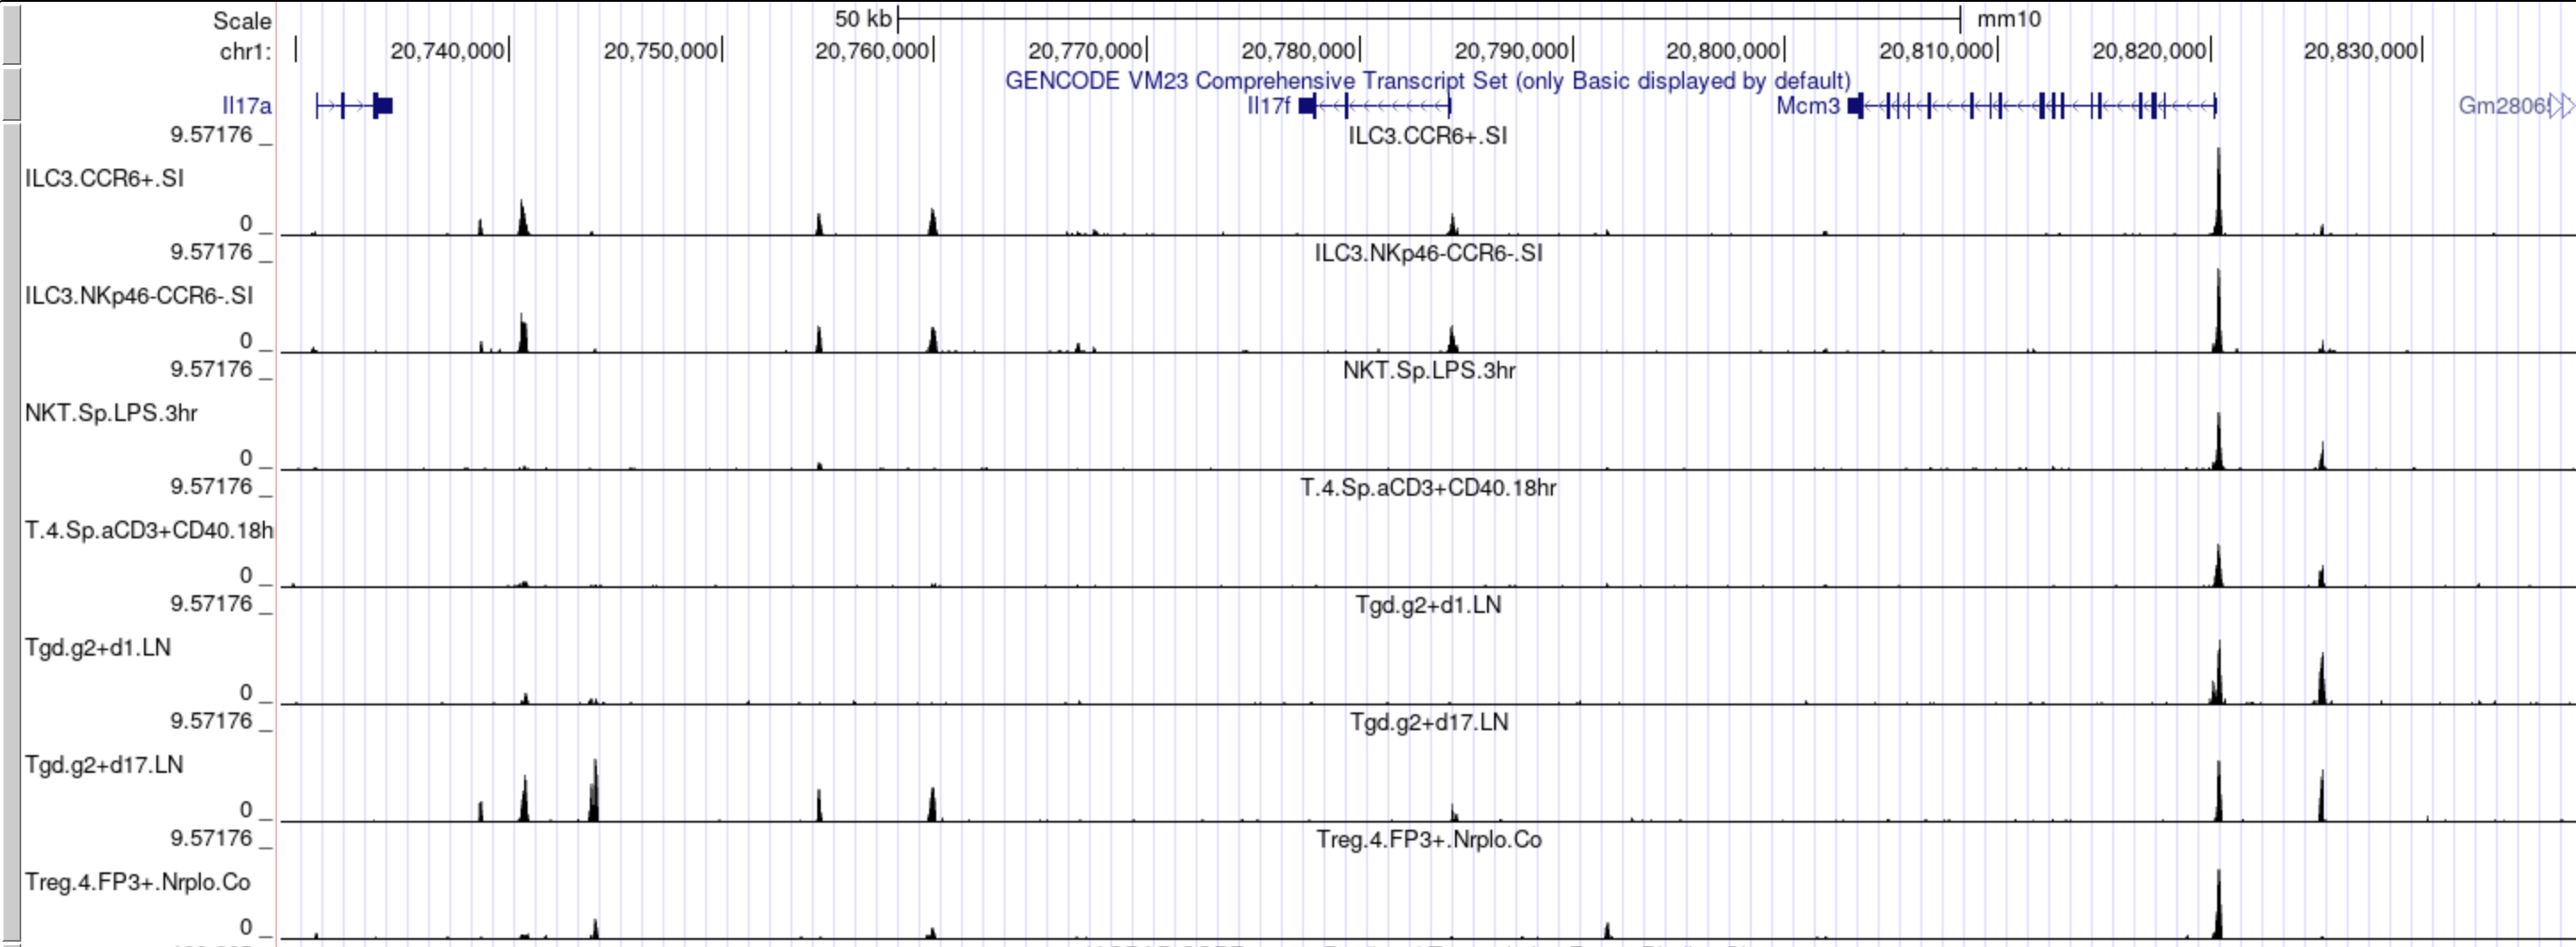

some potential transcription factor for the unique peak from JASPAR (UCSC Genome Browser on Mouse)
- some of these transcription factors are also expressed in IL17 producing Tgd cells

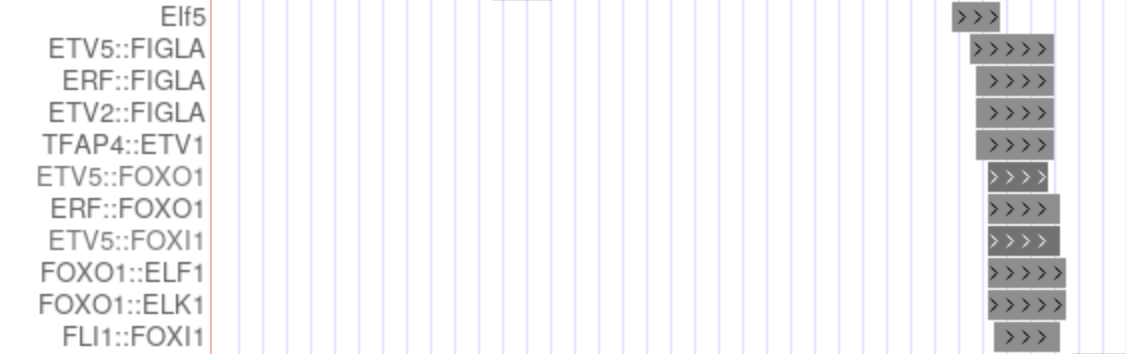

### see if threre are any cells with the unique peak or a peak at the TSS, that do not express IL17f

expression values of Il17f across all cell types

In [51]:
IL17f_expr = RNA_seq_val[RNA_seq_val.index == "Il17f"].copy()
IL17f_expr

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Il17f,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,1.024819,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.13509,1.017884,1.040295,1.017884,1.021351


look at the TSS peak across all cell types

In [52]:
IL17f_TSS_ATAC = ATAC_seq_IL17[ATAC_seq_IL17["Summit"] == 20784347].copy()
IL17f_TSS_ATAC

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
14,ImmGenATAC1219.peak_2095,chr1,20784347,0.55,11.49,1.0,Il17f,"Il17a,Il17f,Mcm3",0.41,0.71,...,2.1,1.81,1.14,0.11,1.82,1.94,0.1,1.92,3.39,0.94


looking at the unique peak across all cell types

In [53]:
IL17f_unique_peak_ATAC = ATAC_seq_IL17[ATAC_seq_IL17["Summit"] == 20744070].copy()
IL17f_unique_peak_ATAC

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
8,ImmGenATAC1219.peak_2086,chr1,20744070,0.0,7.53,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.41,0.1,...,0.44,0.36,0.11,0.53,0.11,0.56,1.26,0.11,1.04,1.26


test the unique peaks value against to other cell types using a one sample t-test

In [54]:
import scipy.stats as stats

unique_peak_others = IL17f_unique_peak_ATAC[IL17f_unique_peak_ATAC.columns[8:]].copy()
unique_peak_others = unique_peak_others.drop("Tgd.g2+d17.LN", axis=1)

unique_peak_others = unique_peak_others.melt()["value"].to_list()

In [55]:
t_stat, p_value = stats.ttest_1samp(unique_peak_others, popmean=IL17f_unique_peak_ATAC["Tgd.g2+d17.LN"])
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -279.929504000158
p-value: 1.3310975317788773e-131


- the expression of IL17f seems to be quite promotor driven, because the OCR at the TSS is only active in cell types expressing IL17f (probably not regulated by silencers)
- the peak we found in IL17f expressing Tgd cells is very unique for them and is only slightly active in Treg cells (not producing IL17f), but not in any others
    - the peak value is significantly different from the other ATACseq values at that summit (very low p-value) 

### test if difference in OCRs is significant between Tgd.g2+d17.LN and Tgd.g2+d1.LN aswell as ILC3.NKp46-CCR6-.SI

I am using a paired t-test and also a wilcoxon rank sum test to compare the chromatin landscape between cell types

In [56]:
from scipy.stats import wilcoxon
from scipy.stats import ttest_rel

In [57]:
stat, p = wilcoxon(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["Tgd.g2+d1.LN"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 161.0
p = 0.1459994912147522


In [58]:
stat, p = wilcoxon(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["ILC3.NKp46-CCR6-.SI"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 204.0
p = 0.5698575973510742


In [59]:
stat, p = ttest_rel(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["Tgd.g2+d1.LN"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 2.4046840016438136
p = 0.022795711214076995


In [60]:
stat, p = ttest_rel(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["ILC3.NKp46-CCR6-.SI"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 1.5552372352372033
p = 0.1307365282851432


When comparing the whole chromatin landscape around Il17f the difference is not signifikant most of the time, because most ATAC peaks are present in all Il17f expressing cell types.